## Loading Data

In [ ]:
# Import Python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score)
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries have been imported!")

Libraries have been imported!


In [ ]:
# Load data, if it exists

try:
    df = pd.read_csv('american_bankruptcy.csv')
    print("Dataset successfully loaded!")
except FileNotFoundError as e:
    print("Error loading dataset. Please ensure the file is in the same directory as this Colab workbook.")

Dataset successfully loaded!


In [ ]:
# Map dataset columns to make them readable
COLMAP = {
    "X1": "current_assets",     "X2": "cogs",               "X3": "dep_amort",
    "X4": "ebitda",             "X5": "inventory",          "X6": "net_income",
    "X7": "receivables",        "X8": "market_value",       "X9": "net_sales",
    "X10": "total_assets",      "X11": "lt_debt",           "X12": "ebit",
    "X13": "gross_profit",      "X14": "curr_liabilities",  "X15": "retained_earnings",
    "X16": "total_revenue",     "X17": "total_liabilities", "X18": "total_opex",
}
df = df.rename(columns=COLMAP)
RAW_DOLLAR_COLS = list(COLMAP.values())
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns, "
      f"{df['company_name'].nunique():,} unique firms, years "
      f"{df['year'].min()}-{df['year'].max()}")

Dataset: 78,682 rows, 21 columns, 8,971 unique firms, years 1999-2018


## Data Cleaning

In [ ]:
# Check if there are any missing values
nulls = df.isnull().sum()
print("Total missing values:", nulls.sum())
assert nulls.sum() == 0, f"Error: Missing values found!\n{nulls[nulls > 0]}"

# Count number of unique and duplicate firms
n_firms = df["company_name"].nunique()
print(f"Unique firms: {n_firms:,}")
dupes = df.duplicated(["company_name", "year"]).sum()
print(f"Duplicate (firm, year) rows: {dupes}")
assert dupes == 0, "Error: Duplicate (firm, year) tuples found!"

# Sort dataset by company name and year
df = df.sort_values(["company_name", "year"]).reset_index(drop=True)
print("\n")

# Is a firm listed as 'alive' before it goes bankrupt, or is it 'failed' all the way?
labels_per_firm = df.groupby("company_name")["status_label"].nunique()
print(f"Firms with more than one distinct label: "
      f"{(labels_per_firm > 1).sum()} of {n_firms:,}")

# The label is constant per firm! Every historical row of a failed firm
# says 'failed'. We should relabel this and only keep 'failed' on
# the firm's final observed year, and relabel all earlier years as 'alive'.
final_year = df.groupby("company_name")["year"].transform("max")
is_final_row = df["year"] == final_year
df["target"] = ((df["status_label"] == "failed") & is_final_row).astype(int)
relabeled = ((df["status_label"] == "failed") & ~is_final_row).sum()
print(f"Relabeled {relabeled:,} pre-final rows of failed firms "
      f"to alive. Positive instances (bankrupt next year): {df['target'].sum()}")

# Verify that our relabeling worked
failed_firms = df.loc[df["status_label"] == "failed", "company_name"].unique()
rows_after_final = df[(df["company_name"].isin(failed_firms)) &
                      (df["year"] > final_year)]
print(f"Failed-firm rows appearing after final year: "
      f"{len(rows_after_final)}")
print("\n")

# Number of firms with year gaps (matters for trend features later)
year_gap = df.groupby("company_name")["year"].diff()
firms_with_gaps = df.loc[year_gap > 1, "company_name"].nunique()
print(f"Firms with gap years in their history: {firms_with_gaps} "
      f"(trend features will be masked across gaps)")

Total missing values: 0
Unique firms: 8,971
Duplicate (firm, year) rows: 0


Firms with more than one distinct label: 0 of 8,971
Relabeled 4,611 pre-final rows of failed firms to alive. Positive instances (bankrupt next year): 609
Failed-firm rows appearing after final year: 0


Firms with gap years in their history: 710 (trend features will be masked across gaps)


## Exploratory Data Analysis

Raw row-level label distribution:
status_label
alive     0.9337
failed    0.0663
Corrected positive rate after relabel: 0.7740% (609 of 78,682 rows)


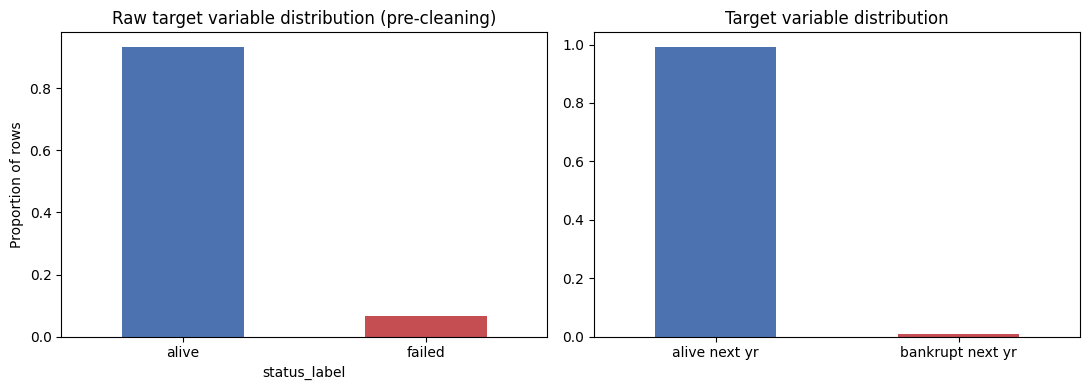

In [ ]:
# Graph distribution of target variable
# Also graph the 'corrected' target variable that only counts the last year
raw_dist = df["status_label"].value_counts(normalize=True)
true_rate = df["target"].mean()
print("Raw row-level label distribution:")
print(raw_dist.round(4).to_string())
print(f"Corrected positive rate after relabel: {true_rate:.4%} "
      f"({df['target'].sum()} of {len(df):,} rows)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
raw_dist.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"], rot=0)
axes[0].set_title("Raw target variable distribution (pre-cleaning)")
axes[0].set_ylabel("Proportion of rows")
pd.Series({"alive next yr": 1 - true_rate, "bankrupt next yr": true_rate}) \
    .plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"], rot=0)
axes[1].set_title("Target variable distribution")
plt.tight_layout(); plt.show()

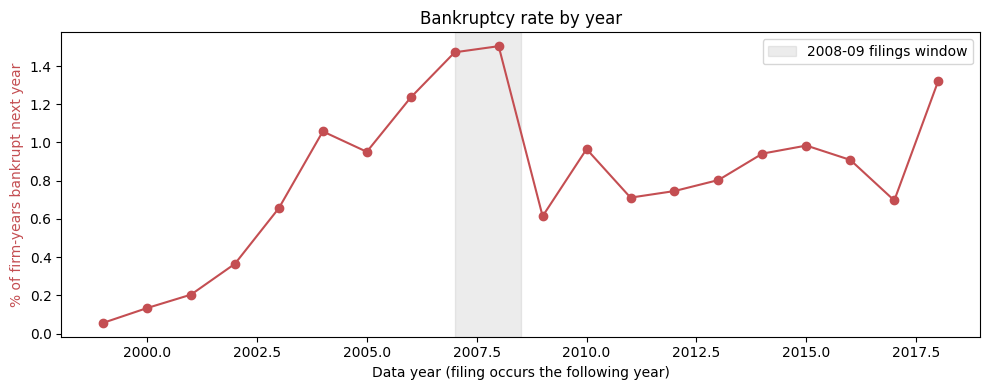

Class counts by split window:
  train (1999-2011): rows=55,927  positives= 403  rate=0.721%
  val   (2012-2014): rows=10,473  positives=  87  rate=0.831%
  test  (2015-2018): rows=12,282  positives= 119  rate=0.969%


In [ ]:
# Graph Bankruptcy rate by year, counts by split
# Note: Data year X = the year BEFORE filing,
# so a spike at 2007-2008 corresponds to 2008-2009 filings.
by_year = df.groupby("year").agg(positives=("target", "sum"),
                                 rows=("target", "size"))
by_year["rate"] = by_year["positives"] / by_year["rows"]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(by_year.index, by_year["rate"] * 100, marker="o", color="#C44E52")
ax1.set_xlabel("Data year (filing occurs the following year)")
ax1.set_ylabel("% of firm-years bankrupt next year", color="#C44E52")
ax1.axvspan(2007, 2008.5, alpha=0.15, color="gray",
            label="2008-09 filings window")
ax1.set_title("Bankruptcy rate by year")
ax1.legend()
plt.tight_layout(); plt.show()

# Build training/validation/testing splits
splits = {"train (1999-2011)": (1999, 2011),
          "val   (2012-2014)": (2012, 2014),
          "test  (2015-2018)": (2015, 2018)}
print("Class counts by split window:")
for name, (lo, hi) in splits.items():
    m = df["year"].between(lo, hi)
    print(f"  {name}: rows={m.sum():>6,}  positives={int(df.loc[m,'target'].sum()):>4}"
          f"  rate={df.loc[m,'target'].mean():.3%}")

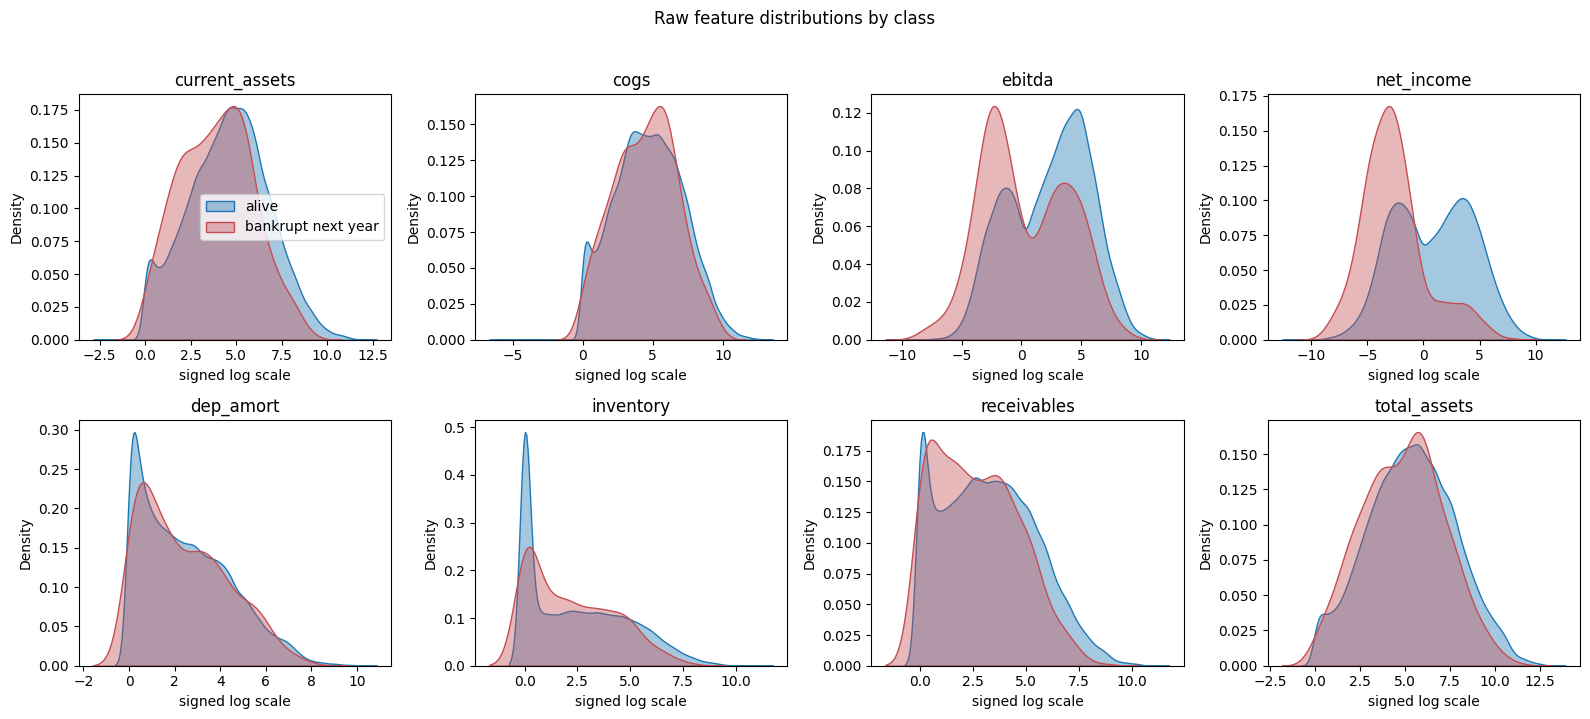

In [ ]:
# Graph feature distributions by class
# Use a signed-log x-axis so heavy tails don't flatten the comparison visually.
EDA_features = ["current_assets", "cogs", "ebitda", "net_income",
             "dep_amort", "inventory", "receivables", "total_assets"]
slog = lambda s: np.sign(s) * np.log1p(np.abs(s))
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), EDA_features):
    sns.kdeplot(slog(df.loc[df["target"] == 0, col]), ax=ax, label="alive",
                fill=True, alpha=0.4)
    sns.kdeplot(slog(df.loc[df["target"] == 1, col]), ax=ax, label="bankrupt next year",
                fill=True, alpha=0.4, color="#C44E52")
    ax.set_title(col); ax.set_xlabel("signed log scale")
axes[0, 0].legend()
fig.suptitle("Raw feature distributions by class", y=1.02)
plt.tight_layout(); plt.show()

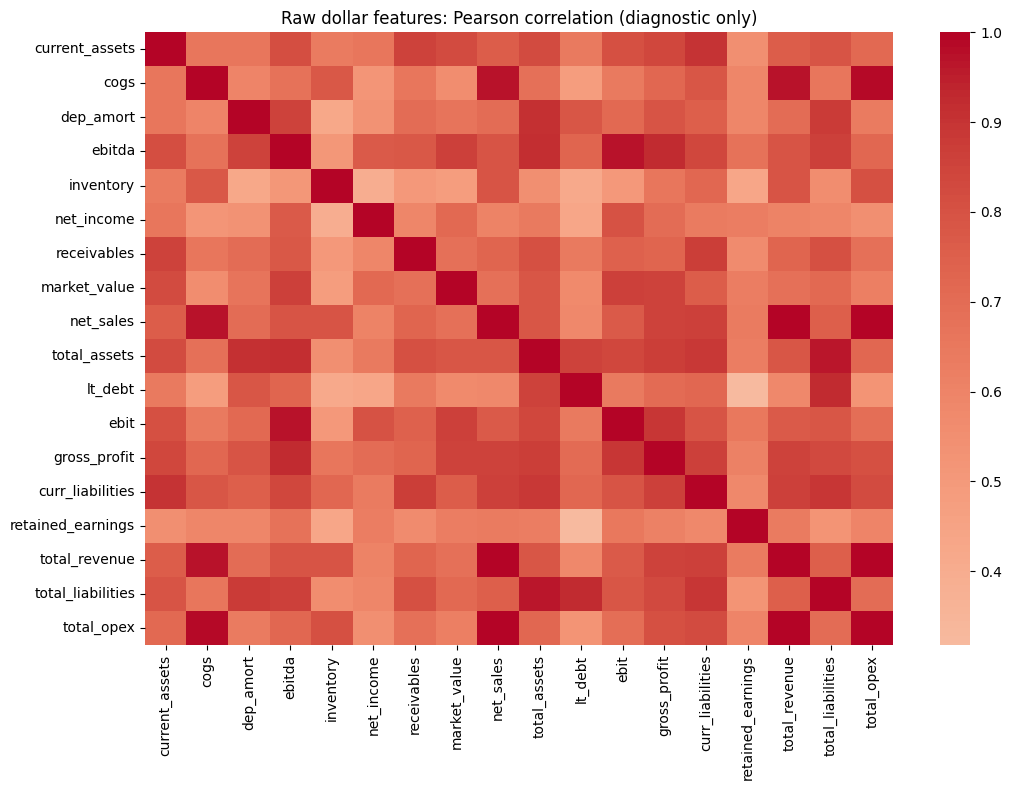

31 raw pairs exceed r =|0.85|, likely driven by firm size.


In [ ]:
# Heatmap of raw-feature correlations
corr_raw = df[RAW_DOLLAR_COLS].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr_raw, cmap="coolwarm", center=0, annot=False)
plt.title("Raw dollar features: Pearson correlation (diagnostic only)")
plt.tight_layout(); plt.show()
high = [(a, b, corr_raw.loc[a, b]) for i, a in enumerate(RAW_DOLLAR_COLS)
        for b in RAW_DOLLAR_COLS[i + 1:] if abs(corr_raw.loc[a, b]) > 0.85]
print(f"{len(high)} raw pairs exceed r =|0.85|, likely driven by firm size.")

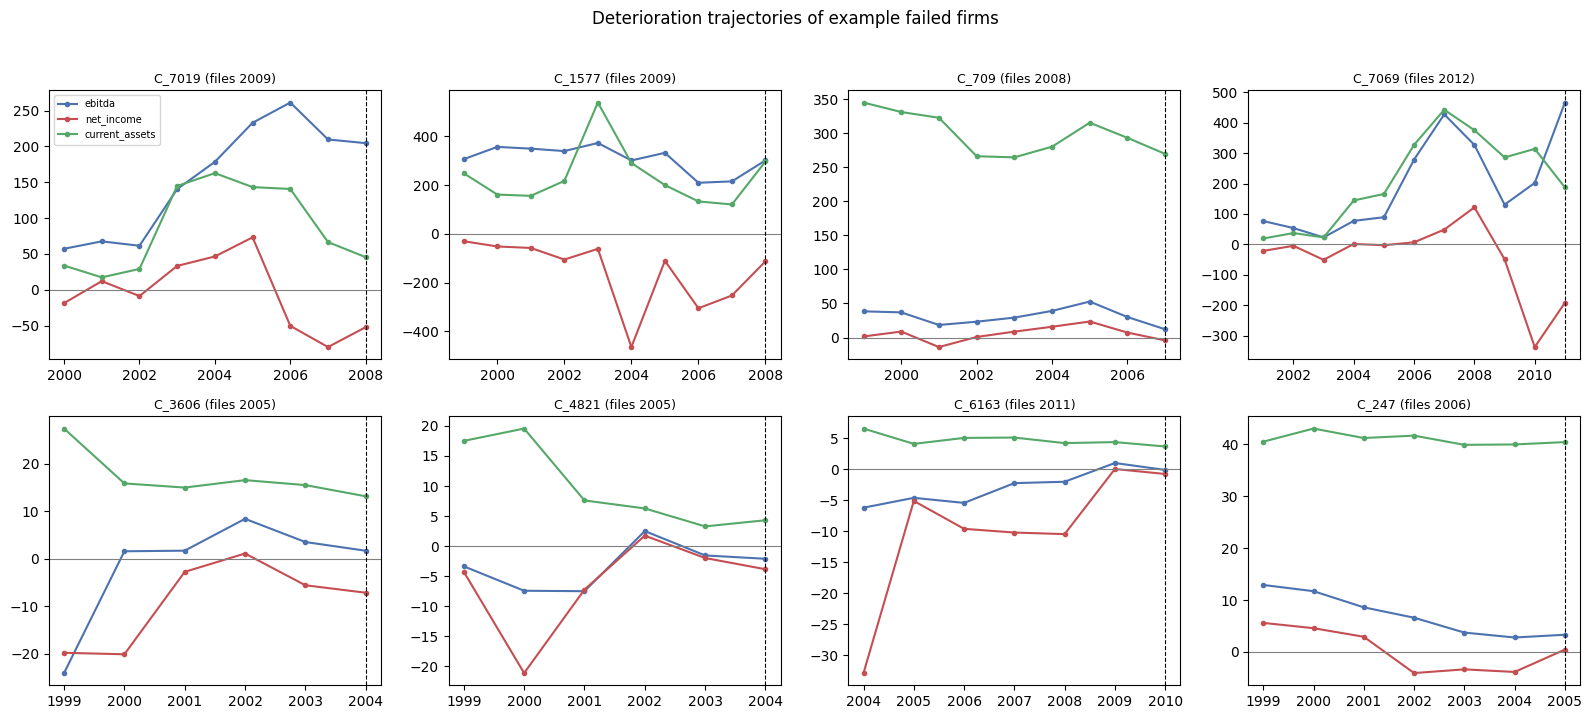

In [ ]:
# Plot the bankruptcy trajectory of specific example firms, to see what happened
hist_len = df[df["company_name"].isin(failed_firms)] \
    .groupby("company_name")["year"].count()
traj_firms = hist_len[hist_len >= 6].sample(8, random_state=42).index
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=False)
for ax, firm in zip(axes.ravel(), traj_firms):
    g = df[df["company_name"] == firm]
    for col, c in [("ebitda", "#4C72B0"), ("net_income", "#C44E52"),
                   ("current_assets", "#55A868")]:
        ax.plot(g["year"], g[col], marker=".", label=col, color=c)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(g["year"].max(), color="black", ls="--", lw=0.8)
    ax.set_title(f"{firm} (files {g['year'].max() + 1})", fontsize=9)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Deterioration trajectories of example failed firms", y=1.02)
plt.tight_layout(); plt.show()

1st/99th percentiles of raw features:
                      p01      p99
current_assets        0.1  13626.8
cogs                  0.0  25674.4
dep_amort             0.0   1804.4
ebitda             -110.2   6517.2
inventory             0.0   3421.7
net_income         -627.7   3047.6
receivables           0.0   4848.5
market_value          0.6  60436.0
net_sales             0.0  38053.1
total_assets          0.2  46434.3
lt_debt               0.0  12931.2
ebit               -193.4   4746.2
gross_profit        -60.6  12568.8
curr_liabilities      0.3  10304.4
retained_earnings -3133.8  13321.3
total_revenue         0.0  38053.1
total_liabilities     0.3  30986.9
total_opex            0.7  31905.7


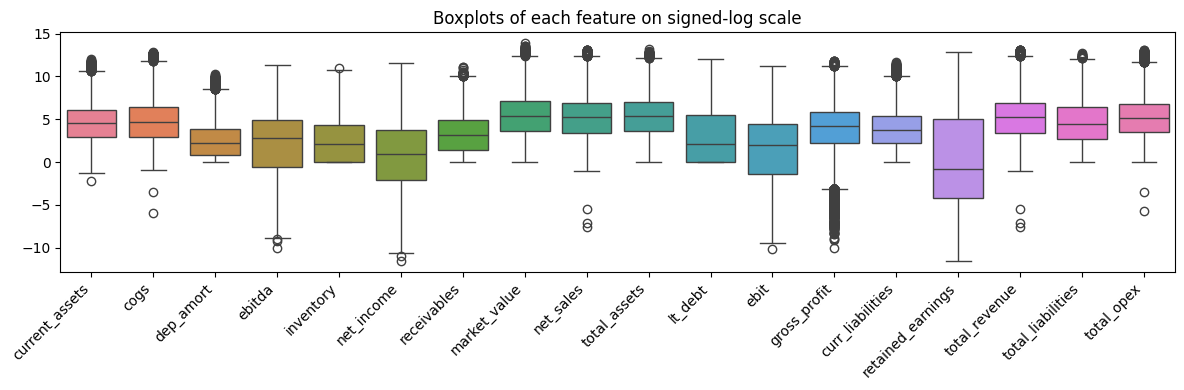

In [ ]:
# Analysis of outliers
pct = df[RAW_DOLLAR_COLS].quantile([0.01, 0.99]).T
pct.columns = ["p01", "p99"]
print("1st/99th percentiles of raw features:")
print(pct.round(1).to_string())
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df[RAW_DOLLAR_COLS].apply(slog), ax=ax)
ax.set_title("Boxplots of each feature on signed-log scale")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## Feature Engineering

In [ ]:
# Feature engineering: Ratios, trends, Z-Scores
# All feature engineering occurs before train/val/test split
# Anything that is fit only on training is fit on the TRAIN_MASK

# Build training mask
TRAIN_MASK = df["year"] <= 2011

# Build financial ratios
# If a denominator is 0 or close to 0, return NaN and impute later on
def safe_div(num, den, floor=1e-6):
    """Ratio with near-zero/negative denominators set to NaN."""
    out = num / den.where(den.abs() >= floor)
    return out.replace([np.inf, -np.inf], np.nan)

# Flag firms that have no inventory, so they don't get imputed
# This is actually 25% of the data!
df["inventory_is_zero"] = (df["inventory"] == 0).astype(int)
print(f"Rows with zero inventory: {df['inventory_is_zero'].sum():,} "
      f"({df['inventory_is_zero'].mean():.1%})")

# This is what we've all been waiting for
# Build the Altman Z-Score
df["altman_x1"] = safe_div(df["current_assets"] - df["curr_liabilities"], df["total_assets"])
df["altman_x2"] = safe_div(df["retained_earnings"], df["total_assets"])
df["altman_x3"] = safe_div(df["ebit"], df["total_assets"])
df["altman_x4"] = safe_div(df["market_value"], df["total_liabilities"])
df["altman_x5"] = safe_div(df["net_sales"], df["total_assets"])
df["altman_z"] = (1.2 * df["altman_x1"] + 1.4 * df["altman_x2"] +
                  3.3 * df["altman_x3"] + 0.6 * df["altman_x4"] +
                  1.0 * df["altman_x5"])

# Profitability metrics
df["roa"]          = safe_div(df["net_income"], df["total_assets"])
df["ebitda_ta"]    = safe_div(df["ebitda"], df["total_assets"])
df["net_margin"]   = safe_div(df["net_income"], df["total_revenue"].where(df["total_revenue"] > 0))
df["gross_margin"] = safe_div(df["gross_profit"], df["net_sales"].where(df["net_sales"] > 0))
# Leverage metrics
df["liab_ta"]   = safe_div(df["total_liabilities"], df["total_assets"])
df["ltdebt_ta"] = safe_div(df["lt_debt"], df["total_assets"])
# Liquidity & efficiency metrics
df["current_ratio"]      = safe_div(df["current_assets"], df["curr_liabilities"])
df["inventory_turnover"] = safe_div(df["cogs"], df["inventory"])
df["dso"]                = safe_div(df["receivables"], df["net_sales"].where(df["net_sales"] > 0)) * 365

# Remember the year gaps from earlier?
# Let's average out the changes so we have a picture of change per year
g = df.groupby("company_name")
gap1 = g["year"].diff().eq(1)
gap2 = gap1 & gap1.groupby(df["company_name"]).shift(1).fillna(False)

# Gap changes in each variable
df["d_ebitda_ta"] = (g["ebitda"].diff() / df["total_assets"]).where(gap1)
df["d_net_income_ta"] = (g["net_income"].diff() / df["total_assets"]).where(gap1)
df["pct_chg_ca"] = (g["current_assets"].pct_change().where(gap1).replace([np.inf, -np.inf], np.nan))
df["ebitda_slope2_ta"] = ((df["ebitda"] - g["ebitda"].shift(2)) / 2 / df["total_assets"]).where(gap2)
df["d_inv_turnover"] = g["inventory_turnover"].diff().where(gap1)

# Consecutive years of negative net income
neg = (df["net_income"] < 0).astype(int)
block = ((neg != neg.shift()) | (df["company_name"] != df["company_name"].shift())).cumsum()
df["consec_neg_ni"] = neg.groupby(block).cumsum()

# Any undefined trends are imputed as 0, plus a history counter is added
TREND_COLS = ["d_ebitda_ta", "d_net_income_ta", "pct_chg_ca",
              "ebitda_slope2_ta", "d_inv_turnover"]
df[TREND_COLS] = df[TREND_COLS].fillna(0)
df["years_of_history"] = g.cumcount() + 1

# Number of NaN counts
RATIO_COLS = ["altman_x1", "altman_x2", "altman_x3", "altman_x4", "altman_x5",
              "roa", "ebitda_ta", "net_margin", "gross_margin",
              "liab_ta", "ltdebt_ta", "current_ratio", "inventory_turnover",
              "dso", "altman_z"]
print("NaN counts before imputation (zero/negative denominators):")
print(df[RATIO_COLS].isnull().sum().loc[lambda s: s > 0].to_string())

Rows with zero inventory: 19,701 (25.0%)
NaN counts before imputation (zero/negative denominators):
net_margin               13
gross_margin             13
inventory_turnover    19701
dso                      13


Winsorized ratios/trends at train-derived 1st/99th pct.
total_assets skew before: 13.6
log_total_assets skew after: -0.01


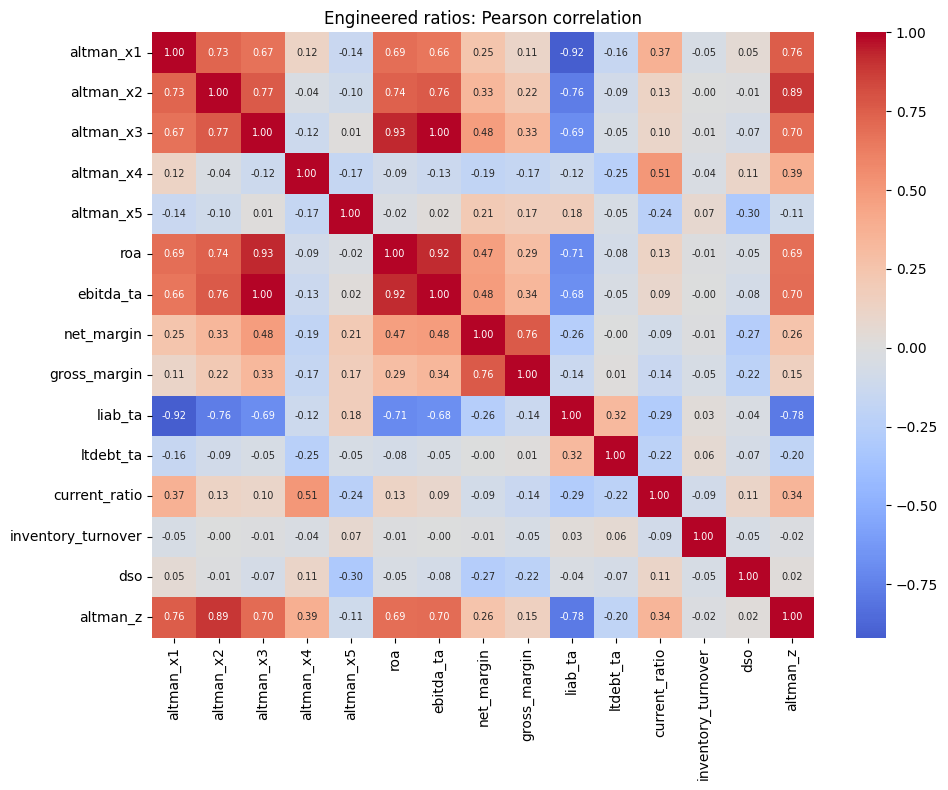

Ratio pairs above r =|0.85| that may risk multicollinearity:
  altman_x1 vs liab_ta: -0.92
  altman_x2 vs altman_z: +0.89
  altman_x3 vs roa: +0.93
  altman_x3 vs ebitda_ta: +1.00
  roa vs ebitda_ta: +0.92
Note: altman_z correlating with its own components is likely expected.


In [ ]:
# Continue the cleaning: Winsorize, impute, and transform data

# Winsorize engineered ratios and trend features at train-window 1st/99th pct
CAP_COLS = RATIO_COLS + TREND_COLS
caps = df.loc[TRAIN_MASK, CAP_COLS].quantile([0.01, 0.99])
df[CAP_COLS] = df[CAP_COLS].clip(lower=caps.loc[0.01], upper=caps.loc[0.99], axis=1)
print("Winsorized ratios/trends at train-derived 1st/99th pct.")

# Impute all remaining NaNs with TRAIN medians only
medians = df.loc[TRAIN_MASK, RATIO_COLS].median()
df[RATIO_COLS] = df[RATIO_COLS].fillna(medians)

# Size control: Skew check, train-cap winsorize, then log1p.
print(f"total_assets skew before: {df['total_assets'].skew():.1f}")
ta_caps = df.loc[TRAIN_MASK, "total_assets"].quantile([0.01, 0.99])
df["log_total_assets"] = np.log1p(df["total_assets"].clip(ta_caps[0.01], ta_caps[0.99]))
print(f"log_total_assets skew after: {df['log_total_assets'].skew():.2f}")

# Ratio correlation heatmap
corr_ratio = df[RATIO_COLS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_ratio, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7})
plt.title("Engineered ratios: Pearson correlation")
plt.tight_layout(); plt.show()
pairs = [(a, b, corr_ratio.loc[a, b]) for i, a in enumerate(RATIO_COLS)
         for b in RATIO_COLS[i + 1:] if abs(corr_ratio.loc[a, b]) > 0.85]
print("Ratio pairs above r =|0.85| that may risk multicollinearity:")
for a, b, c in pairs:
    print(f"  {a} vs {b}: {c:+.2f}")
print("Note: altman_z correlating with its own components is likely expected.")

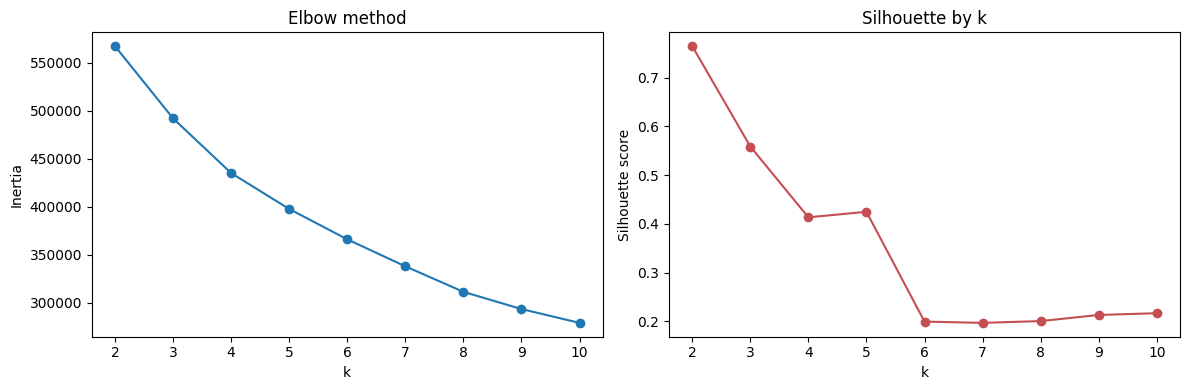

Silhouette-selected k = 2 (silhouette=0.765). 
                    mean   size
industry_cluster               
0                 0.0074  76259
1                 0.0169   2423
Added 2 one-hot cluster columns to df.


In [ ]:
# K-Means unsupervised clustering as a step to further prepare the data for modeling.
# Testing whether unsupervised structure on the engineered ratios recovers segmentation.
# Fit on training split only, then applied to every row.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Exclude altman_z: it's a fixed linear combination of altman_x1-x5, which are
# already in RATIO_COLS, so including it would cause multicollinearity.
CLUSTER_COLS = [c for c in RATIO_COLS if c != "altman_z"]
clust_scaler = StandardScaler().fit(df.loc[TRAIN_MASK, CLUSTER_COLS])
Xc_train = clust_scaler.transform(df.loc[TRAIN_MASK, CLUSTER_COLS])
Xc_all = clust_scaler.transform(df[CLUSTER_COLS])

# Elbow method and silhouette score by k
# Note: Silhouette is O(n^2), which is slow, so it's computed on a fixed subsample.
K_RANGE = range(2, 11)
inertias, sils = [], []
for k in K_RANGE:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_train)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(Xc_train, km_k.labels_, sample_size=5000, random_state=42))

# Plot elbow method and silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")
axes[1].plot(list(K_RANGE), sils, marker="o", color="#C44E52")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette by k")
plt.tight_layout(); plt.show()

# Select a number of clusters
K_OPT = list(K_RANGE)[int(np.argmax(sils))]
print(f"Silhouette-selected k = {K_OPT} (silhouette={max(sils):.3f}). ")
kmeans = KMeans(n_clusters=K_OPT, n_init=10, random_state=42).fit(Xc_train)
df["industry_cluster"] = kmeans.predict(Xc_all)

# Print out clusters
print(df.groupby("industry_cluster")["target"].agg(["mean", "size"]).round(4).to_string())

# One-hot encode and append as candidate model features
# Hopefully this improves model AUC later down the line
cluster_dummies = pd.get_dummies(df["industry_cluster"], prefix="industry_cluster").astype(int)
CLUSTER_FEATURE_COLS = cluster_dummies.columns.tolist()
df[CLUSTER_FEATURE_COLS] = cluster_dummies
print(f"Added {len(CLUSTER_FEATURE_COLS)} one-hot cluster columns to df.")

In [ ]:
# Define feature sets for different model types
FEATURES_ALL = (RATIO_COLS + TREND_COLS +
                ["consec_neg_ni", "years_of_history", "inventory_is_zero",
                 "log_total_assets"] + ["industry_cluster_1"])

# Feature set for Logistic Regression
# Remove industry cluster and altman_z due to potential multicollinearity
FEATURES_LR = [f for f in FEATURES_ALL if f not in ["industry_cluster_1", "altman_z"]]

# Feature set for Decision Tree
# Remove altman_z due to potential overfitting on Altman Z-Score splits
FEATURES_DT = [f for f in FEATURES_ALL if f != "altman_z"]

# Standard FEATURES pointer for tree models
FEATURES = FEATURES_ALL

# Year is used only here, for splitting.
tr = df[df["year"].between(1999, 2011)]
va = df[df["year"].between(2012, 2014)]
te = df[df["year"].between(2015, 2018)]

# Prepare generic splits for tree models
X_tr, y_tr = tr[FEATURES], tr["target"]
X_va, y_va = va[FEATURES], va["target"]
X_te, y_te = te[FEATURES], te["target"]

# Prepare specific splits for Logistic Regression
X_tr_lr, X_va_lr, X_te_lr = tr[FEATURES_LR], va[FEATURES_LR], te[FEATURES_LR]
print(f"Training set: {X_tr.shape[0]} rows")
print(f"LR features ({len(FEATURES_LR)}): {FEATURES_LR}")
print(f"Tree features ({len(FEATURES_ALL)}): {FEATURES_ALL}")

# Prepare specific splits for Decision Tree
X_tr_dt, X_va_dt, X_te_dt = tr[FEATURES_DT], va[FEATURES_DT], te[FEATURES_DT]

# Function to build evaluation of models
def evaluate(name, y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    return {"model": name,
            "ROC-AUC": roc_auc_score(y_true, scores),
            "PR-AUC": average_precision_score(y_true, scores),
            "F1 (failed)": f1_score(y_true, pred),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred),
            "threshold": threshold}

# Function to determine F1 threshhold
def best_f1_threshold(y_true, scores):
    p, r, t = precision_recall_curve(y_true, scores)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    return float(t[np.argmax(f1[:-1])])

# Shared containers for model comparison
results = []
test_scores = {}

# Build the cross validation methodology
from sklearn.model_selection import TimeSeriesSplit

spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight from training data: {spw:.1f}")

# Hyperparameter search on 5 grouped, time-split folds instead of one
# fixed validation window. Each fold's training years end strictly before
# its validation years, preventing future leakage, and any firm with a row in a
# fold's validation window is fully excluded from that fold's training rows.

years = np.sort(df.loc[df["year"] <= 2014, "year"].unique())
tscv = TimeSeriesSplit(n_splits=5, test_size=2)
FOLD_BOUNDARIES = [(years[tr_idx[0]], years[tr_idx[-1]], years[va_idx[0]], years[va_idx[-1]])
                   for tr_idx, va_idx in tscv.split(years)]

def build_grouped_time_folds(df, boundaries, features):
    folds = []
    for (tr_start, tr_end, va_start, va_end) in boundaries:
        val_window = df[df["year"].between(va_start, va_end)]
        val_firms = set(val_window["company_name"])
        train_window_raw = df[df["year"].between(tr_start, tr_end)]
        train_window_clean = train_window_raw[~train_window_raw["company_name"].isin(val_firms)]
        folds.append({
            "X_tr": train_window_clean[features], "y_tr": train_window_clean["target"],
            "X_va": val_window[features], "y_va": val_window["target"],
        })
    return folds

cv_folds = build_grouped_time_folds(df, FOLD_BOUNDARIES, FEATURES)

Training set: 55927 rows
LR features (23): ['altman_x1', 'altman_x2', 'altman_x3', 'altman_x4', 'altman_x5', 'roa', 'ebitda_ta', 'net_margin', 'gross_margin', 'liab_ta', 'ltdebt_ta', 'current_ratio', 'inventory_turnover', 'dso', 'd_ebitda_ta', 'd_net_income_ta', 'pct_chg_ca', 'ebitda_slope2_ta', 'd_inv_turnover', 'consec_neg_ni', 'years_of_history', 'inventory_is_zero', 'log_total_assets']
Tree features (25): ['altman_x1', 'altman_x2', 'altman_x3', 'altman_x4', 'altman_x5', 'roa', 'ebitda_ta', 'net_margin', 'gross_margin', 'liab_ta', 'ltdebt_ta', 'current_ratio', 'inventory_turnover', 'dso', 'altman_z', 'd_ebitda_ta', 'd_net_income_ta', 'pct_chg_ca', 'ebitda_slope2_ta', 'd_inv_turnover', 'consec_neg_ni', 'years_of_history', 'inventory_is_zero', 'log_total_assets', 'industry_cluster_1']
scale_pos_weight from training data: 137.8


## Building the Models

In [ ]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

# Build five-fold cross-validation
C_grid = [0.01, 0.1, 1.0, 10.0, 100.0]
lr_cv_results = []
for C in C_grid:
    fold_scores = []
    for f in cv_folds:
        scaler = StandardScaler().fit(f["X_tr"][FEATURES_LR])
        Xf_tr_s, Xf_va_s = scaler.transform(f["X_tr"][FEATURES_LR]), scaler.transform(f["X_va"][FEATURES_LR])
        lr = LogisticRegression(max_iter=2000, C=C, class_weight="balanced", random_state=42)
        lr.fit(Xf_tr_s, f["y_tr"])
        fold_scores.append(average_precision_score(f["y_va"], lr.predict_proba(Xf_va_s)[:, 1]))
    lr_cv_results.append({"C": C, "pr_auc_mean": np.mean(fold_scores)})
    print(f"C={C}: mean PR-AUC={np.mean(fold_scores):.4f}")

# Print results of cross-validation
best_C = max(lr_cv_results, key=lambda r: r["pr_auc_mean"])["C"]
print(f"Best C: {best_C}")

# Fit the final LR with the CV-selected C on the full training window,
# freeze its threshold on validation, and score the test set once.
lr_scaler = StandardScaler().fit(X_tr_lr)
X_tr_lr_s, X_va_lr_s, X_te_lr_s = (lr_scaler.transform(X)
                                   for X in (X_tr_lr, X_va_lr, X_te_lr))
lr_final = LogisticRegression(max_iter=2000, C=best_C,
                              class_weight="balanced", random_state=42)
lr_final.fit(X_tr_lr_s, y_tr)
lr_thr = best_f1_threshold(y_va, lr_final.predict_proba(X_va_lr_s)[:, 1])
sc = lr_final.predict_proba(X_te_lr_s)[:, 1]
results.append(evaluate("LogReg", y_te, sc, lr_thr))
test_scores["LogReg"] = sc

# Interpretability: coefficients on standardized features
lr_coefs = pd.Series(lr_final.coef_[0], index=FEATURES_LR).sort_values()
print("Final LR coefficients (standardized features):")
print(lr_coefs.round(3).to_string())

C=0.01: mean PR-AUC=0.0298
C=0.1: mean PR-AUC=0.0292
C=1.0: mean PR-AUC=0.0289
C=10.0: mean PR-AUC=0.0288
C=100.0: mean PR-AUC=0.0288
Best C: 0.01
Final LR coefficients (standardized features):
current_ratio        -1.028
altman_x4            -0.486
inventory_is_zero    -0.312
gross_margin         -0.235
log_total_assets     -0.216
pct_chg_ca           -0.213
d_ebitda_ta          -0.132
dso                  -0.128
altman_x1            -0.113
ebitda_slope2_ta     -0.105
inventory_turnover   -0.091
altman_x3            -0.062
d_net_income_ta      -0.024
d_inv_turnover       -0.012
altman_x2             0.015
ebitda_ta             0.036
net_margin            0.064
liab_ta               0.076
altman_x5             0.106
roa                   0.111
ltdebt_ta             0.216
years_of_history      0.357
consec_neg_ni         0.544


In [ ]:
# Model 2: Full Altman Z-Score baseline
# Ranking score = -Z (lower Z = more distressed).
z_te = te["altman_z"]
results.append(evaluate("Altman Z", y_te, -z_te, -1.81))
test_scores["Altman Z"] = -z_te.values
zone = pd.cut(z_te, [-np.inf, 1.81, 2.99, np.inf],
              labels=["distress (<1.81)", "gray (1.81-2.99)", "safe (>2.99)"])
print("Test-set bankruptcy rate by Altman Z-score zone:")
print(te.groupby(zone)["target"].agg(["mean", "size"]).round(4).to_string())

Test-set bankruptcy rate by Altman Z-score zone:
                    mean  size
altman_z                      
distress (<1.81)  0.0209  5030
gray (1.81-2.99)  0.0035  1986
safe (>2.99)      0.0013  5266


In [ ]:
# Model 3: XGBoost (primary)
from xgboost import XGBClassifier

grid = [{"max_depth": d, "learning_rate": lr_, "subsample": ss,
         "colsample_bytree": cs, "min_child_weight": mcw}
        for d in (3, 4, 6)
        for lr_ in (0.05, 0.1)
        for ss, cs, mcw in [(0.8, 0.8, 5), (1.0, 1.0, 1)]]

cv_results = []
for params in grid:
    fold_scores, fold_rounds = [], []
    for f in cv_folds:
        spw_f = (f["y_tr"] == 0).sum() / max((f["y_tr"] == 1).sum(), 1)
        m = XGBClassifier(n_estimators=2000, early_stopping_rounds=50,
                          scale_pos_weight=spw_f, eval_metric="aucpr",
                          tree_method="hist", random_state=42, **params)
        m.fit(f["X_tr"], f["y_tr"], eval_set=[(f["X_va"], f["y_va"])], verbose=False)
        fold_scores.append(average_precision_score(f["y_va"], m.predict_proba(f["X_va"])[:, 1]))
        fold_rounds.append(m.best_iteration + 1)
    cv_results.append({"params": params, "pr_auc_mean": np.mean(fold_scores),
                        "pr_auc_std": np.std(fold_scores), "n_rounds": int(np.median(fold_rounds))})

best_cv = max(cv_results, key=lambda r: r["pr_auc_mean"])
print(f"Best CV mean PR-AUC {best_cv['pr_auc_mean']:.4f} "
      f"(+/-{best_cv['pr_auc_std']:.4f}) with {best_cv['params']}, {best_cv['n_rounds']} rounds")

# Refit the winning hyperparameters on the original single train/val split
# so we still have one clean model that never trained on validation.
# This is what the calibration check later in the notebook relies on (best["model"]).
best = {"params": best_cv["params"], "n_rounds": best_cv["n_rounds"]}
tuning_fit = XGBClassifier(n_estimators=best["n_rounds"], scale_pos_weight=spw,
                           eval_metric="aucpr", tree_method="hist",
                           random_state=42, **best["params"])
tuning_fit.fit(X_tr, y_tr, verbose=False)
best["model"] = tuning_fit
best["pr_auc"] = average_precision_score(y_va, tuning_fit.predict_proba(X_va)[:, 1])

# Threshold frozen from val set predictions of the tuning-stage model,
# so it is selected on data the final model never trained on.
xgb_thr = best_f1_threshold(y_va, best["model"].predict_proba(X_va)[:, 1])

# Retrain on combined 1999-2014 with chosen hyperparameters and the round
# count found by early stopping; evaluate on 2015-2018 test set.
X_trva = pd.concat([X_tr, X_va]); y_trva = pd.concat([y_tr, y_va])
spw_full = (y_trva == 0).sum() / (y_trva == 1).sum()
xgb = XGBClassifier(n_estimators=best["n_rounds"], scale_pos_weight=spw_full,
                    eval_metric="aucpr", tree_method="hist",
                    random_state=42, **best["params"])
xgb.fit(X_trva, y_trva, verbose=False)
sc = xgb.predict_proba(X_te)[:, 1]
results.append(evaluate("XGBoost (primary)", y_te, sc, xgb_thr))
test_scores["XGBoost (primary)"] = sc

Best CV mean PR-AUC 0.1377 (+/-0.0840) with {'max_depth': 4, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1}, 29 rounds


In [ ]:
# Also trying XGBoost with SMOTE (comparison against scale_pos_weight)
from imblearn.over_sampling import SMOTE

X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
print(f"Training set size before SMOTE: {len(y_tr):,} ({y_tr.mean():.3%} positive)")
print(f"Training set size after SMOTE:  {len(y_tr_sm):,} ({y_tr_sm.mean():.3%} positive)")

xgb_sm = XGBClassifier(n_estimators=best["n_rounds"],
                        scale_pos_weight=1,
                        eval_metric="aucpr",
                        tree_method="hist",
                        random_state=42,
                        **best["params"])
xgb_sm.fit(X_tr_sm, y_tr_sm, verbose=False)

# Threshold selected on the unmodified validation set.
sm_thr = best_f1_threshold(y_va, xgb_sm.predict_proba(X_va)[:, 1])
sc = xgb_sm.predict_proba(X_te)[:, 1]
results.append(evaluate("XGBoost (SMOTE)", y_te, sc, sm_thr))
test_scores["XGBoost (SMOTE)"] = sc

Training set size before SMOTE: 55,927 (0.721% positive)
Training set size after SMOTE:  111,048 (50.000% positive)


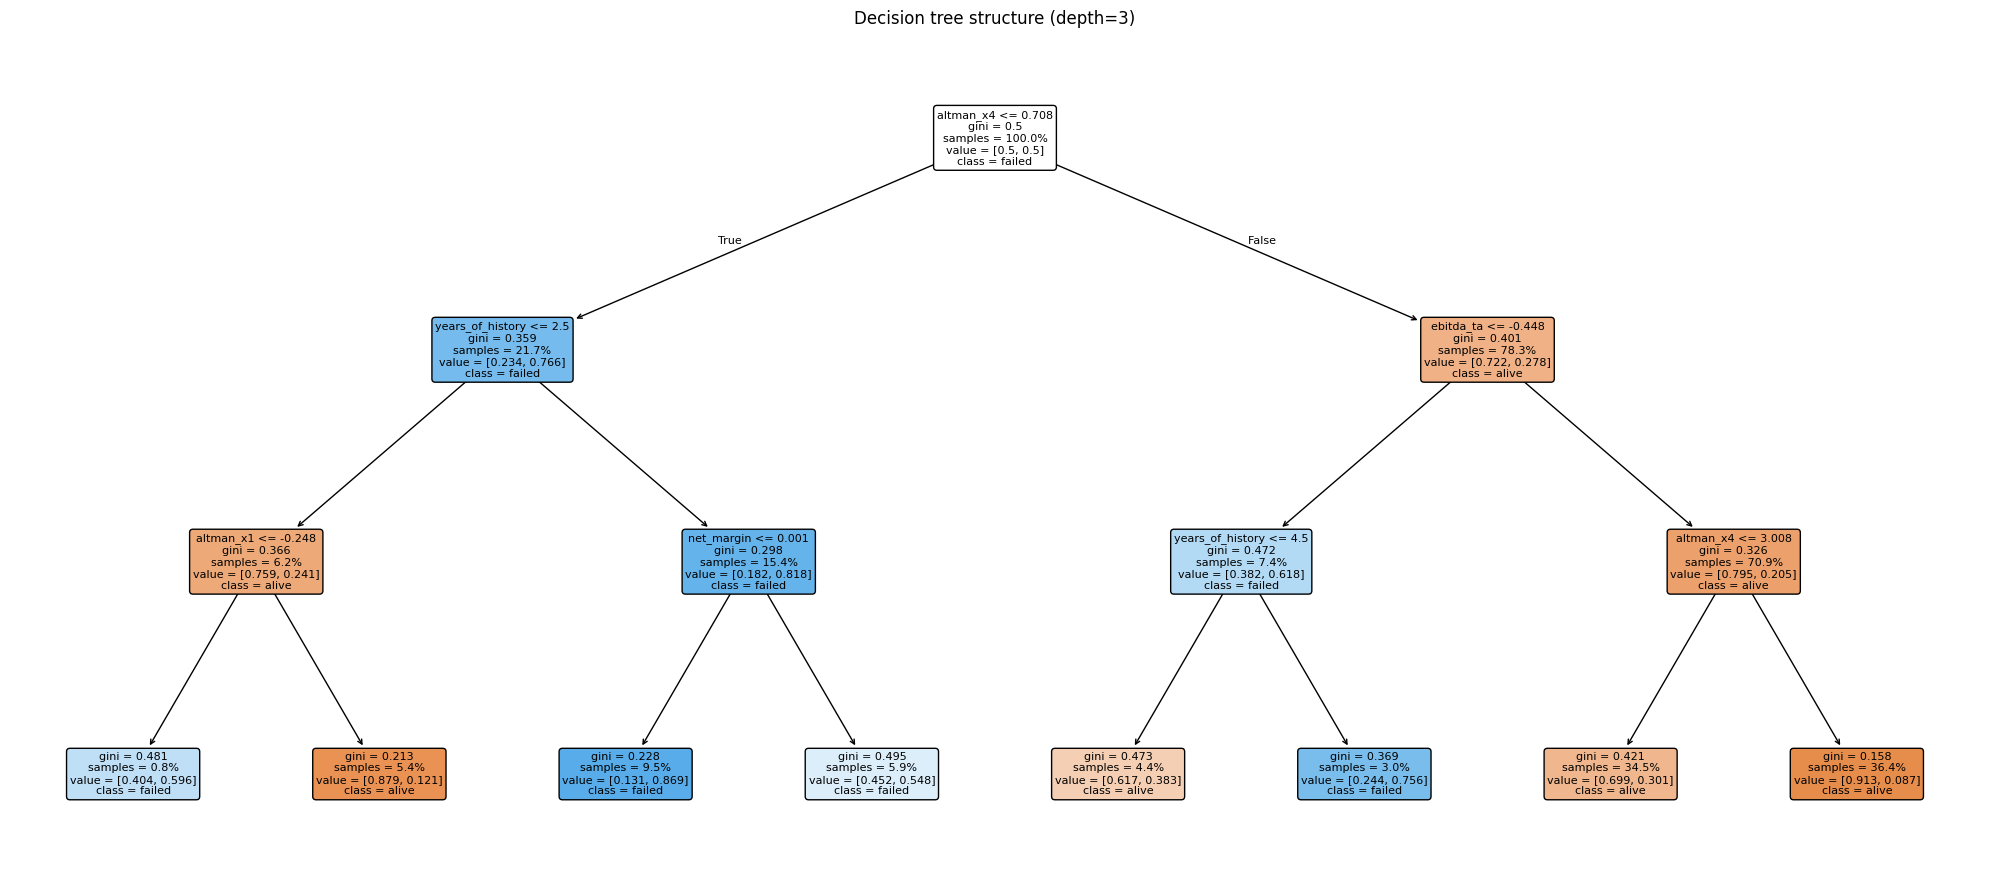

Random Forest top 10 features:
altman_x4           0.1289
liab_ta             0.0905
altman_z            0.0705
years_of_history    0.0553
roa                 0.0521
net_margin          0.0481
current_ratio       0.0454
dso                 0.0412
ebitda_slope2_ta    0.0379
altman_x1           0.0372


In [ ]:
# Model 4: Decision Tree (for interpretability) and Model 5: Random Forest
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Decision Tree: shallow and class-weighted to avoid class imbalance
dt = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt.fit(X_tr_dt, y_tr)
dt_thr = best_f1_threshold(y_va, dt.predict_proba(X_va_dt)[:, 1])
sc = dt.predict_proba(X_te_dt)[:, 1]
results.append(evaluate("Decision Tree (depth=3)", y_te, sc, dt_thr))
test_scores["Decision Tree (depth=3)"] = sc

# Plot decision tree structure
plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=FEATURES_DT, class_names=["alive", "failed"],
          filled=True, rounded=True, fontsize=8, proportion=True)
plt.title("Decision tree structure (depth=3)")
plt.tight_layout(); plt.show()

# Model 5: Random Forest
rf = RandomForestClassifier(n_estimators=500, class_weight="balanced_subsample",
                            random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_thr = best_f1_threshold(y_va, rf.predict_proba(X_va)[:, 1])
sc = rf.predict_proba(X_te)[:, 1]
results.append(evaluate("Random Forest", y_te, sc, rf_thr))
test_scores["Random Forest"] = sc

rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Random Forest top 10 features:")
print(rf_imp.head(10).round(4).to_string())

## Evaluating the Models

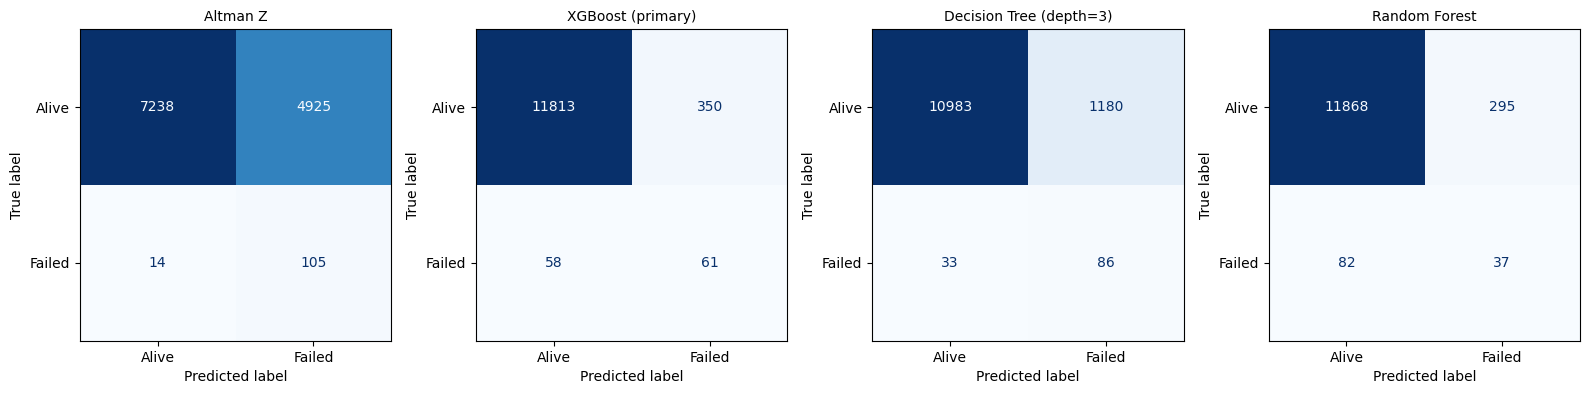

In [ ]:
# Showing confusion matrices for all five models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

results_df = pd.DataFrame(results).set_index("model")
KEEPER_MODELS = [m for m in ["LogReg (balanced)", "Altman Z", "XGBoost (primary)",
                  "Decision Tree (depth=3)", "Random Forest"] if m in results_df.index]

fig, axes = plt.subplots(1, len(KEEPER_MODELS), figsize=(4*len(KEEPER_MODELS), 4))
for ax, name in zip(axes, KEEPER_MODELS):
    thr = results_df.loc[name, "threshold"]
    pred = (test_scores[name] >= thr).astype(int)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Alive", "Failed"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

Test set (2015-2018): 12,282 rows, 119 positives (0.97%). Baseline PR-AUC for a random model = 0.0097
                            ROC-AUC  PR-AUC  F1 (failed)  Precision  Recall  threshold
model                                                                                 
LogReg (balanced, tuned C)   0.7689  0.0268       0.0657     0.0361  0.3613     0.8502
Altman Z                     0.7941  0.0252       0.0408     0.0209  0.8824    -1.8100
XGBoost (primary)            0.9135  0.1629       0.2302     0.1484  0.5126     0.8374
XGBoost (SMOTE)              0.8697  0.0774       0.1324     0.0921  0.2353     0.7894
Decision Tree (depth=3)      0.8832  0.0583       0.1242     0.0679  0.7227     0.8688
Random Forest                0.8946  0.1196       0.1641     0.1114  0.3109     0.0560
LogReg                       0.7689  0.0268       0.0657     0.0361  0.3613     0.8502


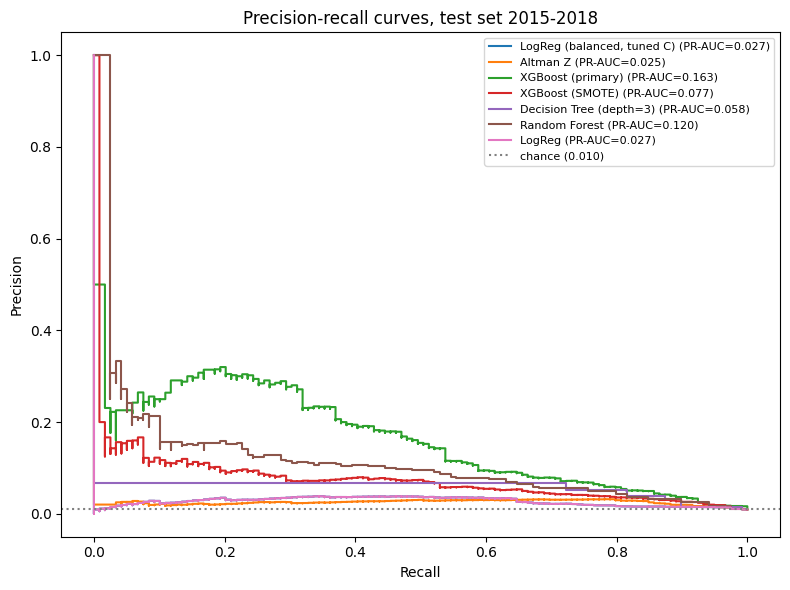

In [ ]:
# Evaluating the models using metrics table and Precision-Recall (PR-AUC) curves
res = pd.DataFrame(results).set_index("model")
print(f"Test set (2015-2018): {len(y_te):,} rows, {y_te.sum()} positives "
      f"({y_te.mean():.2%}). Baseline PR-AUC for a random model = {y_te.mean():.4f}")
print(res.round(4).to_string())

# Plot the curves
plt.figure(figsize=(8, 6))
for name, sc in test_scores.items():
    p, r, _ = precision_recall_curve(y_te, sc)
    plt.plot(r, p, drawstyle="steps-post",
             label=f"{name} (PR-AUC={average_precision_score(y_te, sc):.3f})")
plt.axhline(y_te.mean(), color="gray", ls=":", label=f"chance ({y_te.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-recall curves, test set 2015-2018")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

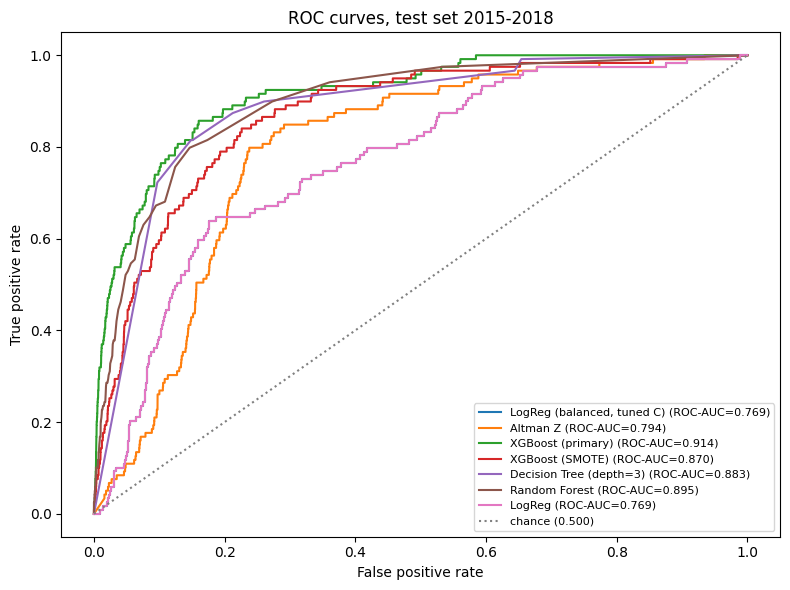

In [ ]:
# Plot ROC curves and AUC on the test set
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, sc in test_scores.items():
    fpr, tpr, _ = roc_curve(y_te, sc)
    plt.plot(fpr, tpr, label=f"{name} (ROC-AUC={roc_auc_score(y_te, sc):.3f})")
plt.plot([0, 1], [0, 1], color="gray", ls=":", label="chance (0.500)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves, test set 2015-2018")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

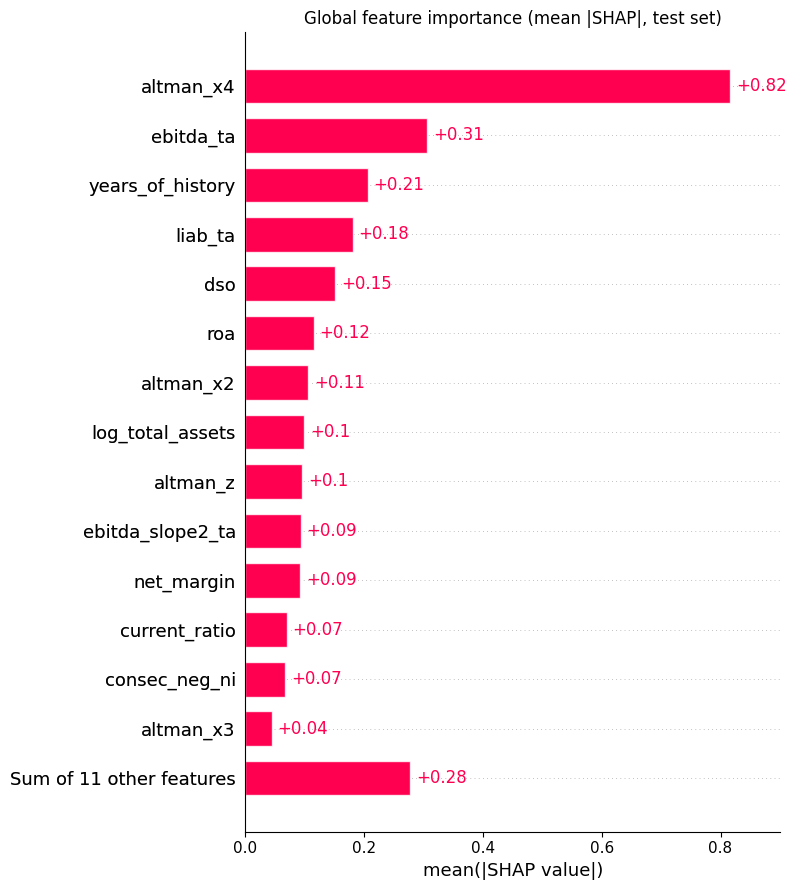

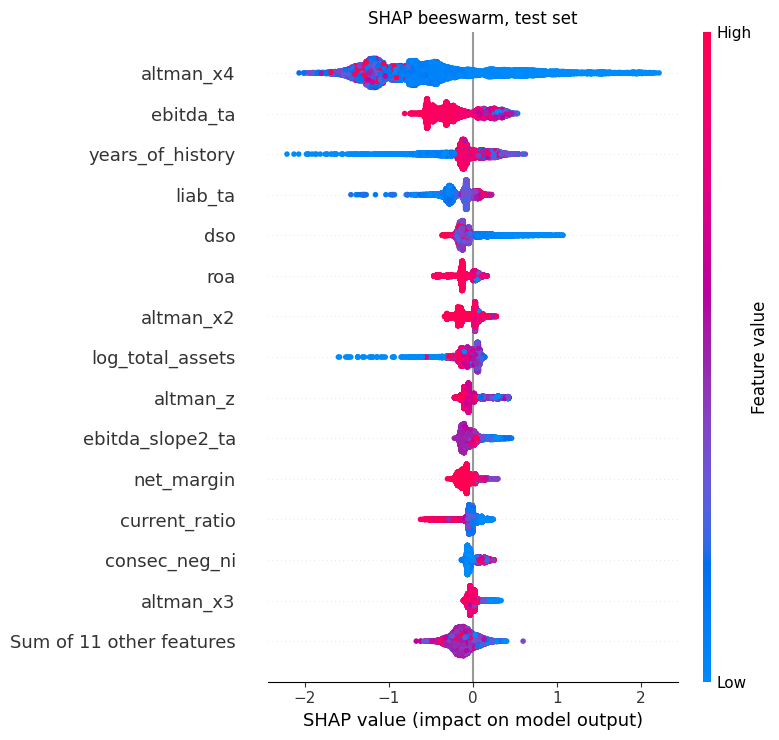

SHAP waterfall | C_8241, data year 2016 (filed 2017), predicted prob 0.931


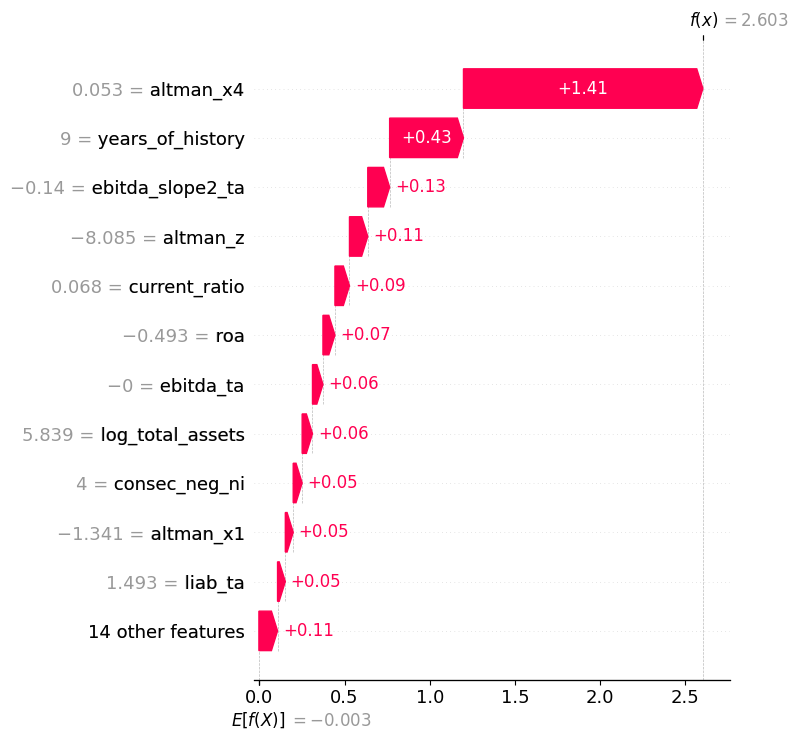

In [ ]:
# Explainability by using SHAP on the test set
import shap
explainer = shap.TreeExplainer(xgb)
sv = explainer(X_te)

# 1. Global importance bar chart
shap.plots.bar(sv, max_display=15, show=False)
plt.title("Global feature importance (mean |SHAP|, test set)")
plt.tight_layout(); plt.show()

# 2. Beeswarm
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP beeswarm, test set")
plt.tight_layout(); plt.show()

# 3. Waterfall for a correctly predicted bankruptcy (core Streamlit deliverable)
correct_pos = np.where((y_te.values == 1) &
                       (test_scores["XGBoost (primary)"] >= xgb_thr))[0]
if len(correct_pos):
    i = correct_pos[np.argmax(test_scores["XGBoost (primary)"][correct_pos])]
    firm, yr = te.iloc[i][["company_name", "year"]]
    print(f"SHAP waterfall | {firm}, data year {int(yr)} (filed {int(yr) + 1}), "
          f"predicted prob {test_scores['XGBoost (primary)'][i]:.3f}")
    shap.plots.waterfall(sv[i], max_display=12, show=False)
    plt.tight_layout(); plt.show()
else:
    print("No correctly predicted bankruptcies at the frozen threshold; "
          "inspect the highest-scored true positives manually.")

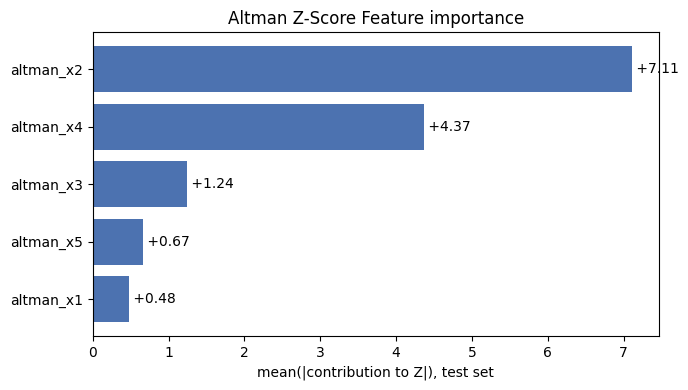

Altman's fixed weights, for reference:
altman_x3    3.3
altman_x2    1.4
altman_x1    1.2
altman_x5    1.0
altman_x4    0.6


In [ ]:
# Feature importance for Altman Z-Score

altman_coefs = {"altman_x1": 1.2, "altman_x2": 1.4, "altman_x3": 3.3,
                "altman_x4": 0.6, "altman_x5": 1.0}

train_means = X_trva[list(altman_coefs.keys())].mean()

altman_contribs = pd.DataFrame({
    name: altman_coefs[name] * (te[name] - train_means[name])
    for name in altman_coefs
})
altman_importance = altman_contribs.abs().mean().sort_values(ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(altman_importance.index[::-1], altman_importance.values[::-1], color="#4C72B0")
ax.set_xlabel("mean(|contribution to Z|), test set")
ax.set_title("Altman Z-Score Feature importance")
for i, v in enumerate(altman_importance.values[::-1]):
    ax.text(v, i, f" +{v:.2f}", va="center")
plt.tight_layout(); plt.show()

# Show fixed weights for reference
print("Altman's fixed weights, for reference:")
print(pd.Series(altman_coefs).sort_values(ascending=False).to_string())

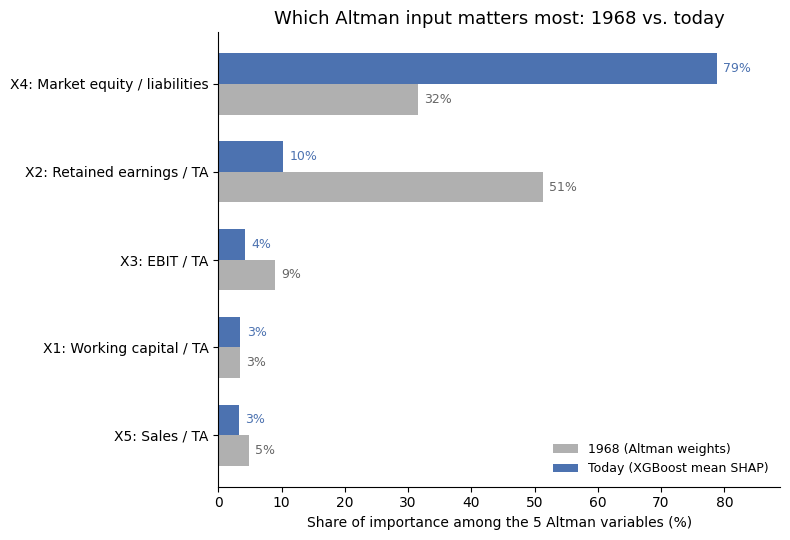

In [ ]:
# Comparing feature importance in 1968 vs today
today_importance_all = pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
today_five = today_importance_all.loc[list(altman_coefs.keys())]

LABELS = {"altman_x1": "X1: Working capital / TA",
          "altman_x2": "X2: Retained earnings / TA",
          "altman_x3": "X3: EBIT / TA",
          "altman_x4": "X4: Market equity / liabilities",
          "altman_x5": "X5: Sales / TA"}

# Normalize both sides to % share of the 5 Altman variables, since raw
# SHAP values and Altman's raw coefficients live on different scales
today_pct = today_five / today_five.sum() * 100
altman_pct = altman_importance / altman_importance.sum() * 100

order = today_pct.sort_values(ascending=True).index
labels = [LABELS[n] for n in order]
y = np.arange(len(order))
h = 0.35

# Plot the results
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(y - h/2, altman_pct[order], height=h, color="#B0B0B0", label="1968 (Altman weights)")
ax.barh(y + h/2, today_pct[order], height=h, color="#4C72B0", label="Today (XGBoost mean SHAP)")

for i, n in enumerate(order):
    ax.text(altman_pct[n] + 1, i - h/2, f"{altman_pct[n]:.0f}%", va="center", fontsize=9, color="#666666")
    ax.text(today_pct[n] + 1, i + h/2, f"{today_pct[n]:.0f}%", va="center", fontsize=9, color="#4C72B0")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Share of importance among the 5 Altman variables (%)")
ax.set_title("Which Altman input matters most: 1968 vs. today", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, max(altman_pct.max(), today_pct.max()) + 10)
plt.tight_layout(); plt.show()

Raw Brier score: 0.1114
Brier score (calibrated): 0.0089


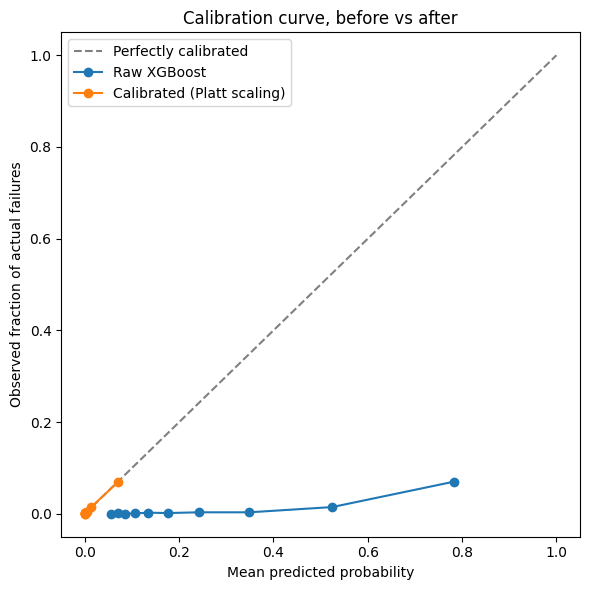

In [ ]:
# Probability calibration model to turn our predictions into percentages
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

tuning_model = best["model"]
raw_probs_te = tuning_model.predict_proba(X_te)[:, 1]

prob_true, prob_pred = calibration_curve(y_te, raw_probs_te, n_bins=10, strategy="quantile")
print(f"Raw Brier score: {brier_score_loss(y_te, raw_probs_te):.4f}")

# Fit a Platt scaling (sigmoid) map on validation only, using the
# tuning-stage model specifically, since it never trained on validation.
calibrated = CalibratedClassifierCV(FrozenEstimator(tuning_model), method="sigmoid")
calibrated.fit(X_va, y_va)
calibrated_probs_te = calibrated.predict_proba(X_te)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_te, calibrated_probs_te, n_bins=10, strategy="quantile")
print(f"Brier score (calibrated): {brier_score_loss(y_te, calibrated_probs_te):.4f}")

# Plot the graph
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", label="Raw XGBoost")
ax.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated (Platt scaling)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction of actual failures")
ax.set_title("Calibration curve, before vs after")
ax.legend()
plt.tight_layout(); plt.show()